# Collocation placement: does WHERE the points sit matter?

At fixed density 20/unit: `latin` (baseline, imported from ../Causal_weighting),
`uniform` (deterministic midpoints), `anchored` (latin + 40 points geometrically packed
into (1e-3, 1] — the direct test of the measured escape-gap loophole). 24 new runs +
12 imported baseline rows.

In [1]:
import json, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25})
FIGURES = Path.cwd() / "figures"; FIGURES.mkdir(exist_ok=True)

rows = [json.loads(open(p).read()) for p in glob.glob("results/runs/*.json")]
df = pd.DataFrame([r for r in rows if not r.get("smoke")])

# latin baseline, imported: causal from ../Causal_weighting, unweighted from ../Initial_pass
cw = pd.read_csv("../Causal_weighting/results/sweep_summary.csv")
ip = pd.read_csv("../Initial_pass/results/sweep_summary.csv")
base = []
for _, r in cw[cw.horizon.isin([14.0, 27.0])].iterrows():
    base.append(dict(arm="causal", horizon=r.horizon, placement="latin",
                     seed=int(r.seed), rel_l2=r.rel_l2))
for _, r in ip[ip.horizon.isin([14.0, 27.0])].iterrows():
    base.append(dict(arm="unweighted", horizon=r.horizon, placement="latin",
                     seed=int(r.seed), rel_l2=r.rel_l2))
df = pd.concat([df, pd.DataFrame(base)], ignore_index=True)
print(df.groupby(["arm", "horizon", "placement"]).rel_l2.median()
        .unstack("placement").to_string(float_format=lambda v: f"{v:.2e}"))

placement           anchored    latin  uniform
arm        horizon                            
causal     14.0     1.97e-04 2.12e-04 5.51e-05
           27.0     9.02e-01 1.90e+00 1.99e+00
unweighted 14.0     7.87e-01 7.93e-01 7.95e-01
           27.0     9.02e-01 9.04e-01 9.10e-01


## The comparison figure

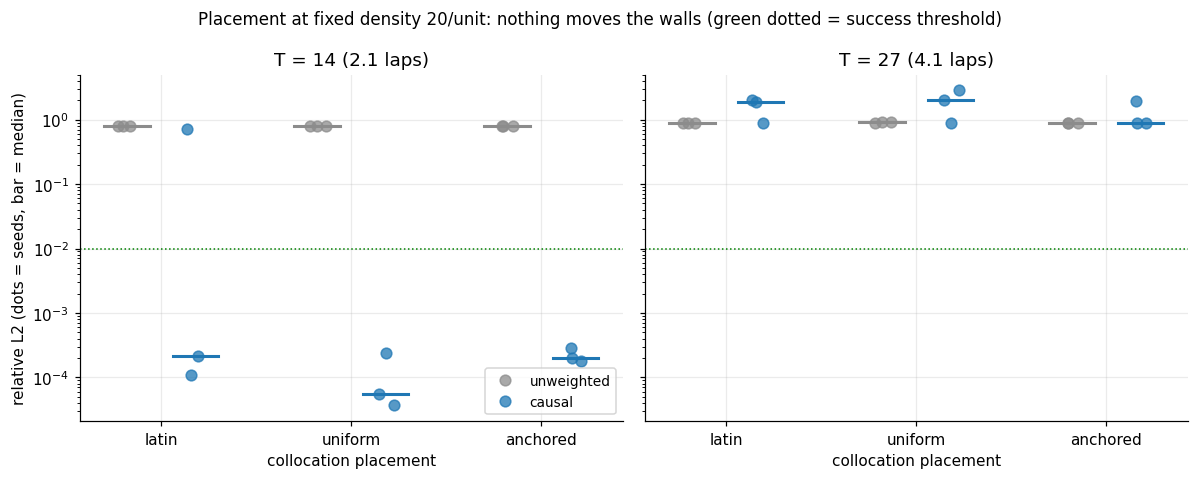

In [2]:
placements = ["latin", "uniform", "anchored"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
for ax, T in zip(axes, [14.0, 27.0]):
    for j, arm in enumerate(["unweighted", "causal"]):
        for i, pl in enumerate(placements):
            g = df[(df.arm == arm) & (df.horizon == T) & (df.placement == pl)]
            x = i + (-0.18 if arm == "unweighted" else 0.18)
            colour = "0.55" if arm == "unweighted" else "C0"
            ax.semilogy([x]*len(g) + np.random.default_rng(i).uniform(-0.05, 0.05, len(g)),
                        g.rel_l2, "o", ms=7, color=colour, alpha=0.75,
                        label=arm if (i == 0 and T == 14.0) else None)
            if len(g):
                ax.plot([x-0.12, x+0.12], [g.rel_l2.median()]*2, "-", color=colour, lw=2)
    ax.set_xticks(range(3), placements)
    ax.axhline(1e-2, color="green", ls=":", lw=1)
    ax.set_title(f"T = {T:g} ({T/6.663287:.1f} laps)")
    ax.set_xlabel("collocation placement")
axes[0].set_ylabel("relative L2 (dots = seeds, bar = median)")
axes[0].legend(fontsize=9)
fig.suptitle("Placement at fixed density 20/unit: nothing moves the walls "
             "(green dotted = success threshold)", fontsize=11)
fig.tight_layout()
fig.savefig(FIGURES / "01_placement_comparison.png", bbox_inches="tight")
plt.show()

## Verdict

- **Unweighted**: placement-independent at both horizons (as it is density-independent) —
  the wall is not a sampling artefact of any kind.
- **Causal, T = 14**: uniform and anchored both land 3/3 seeds at ~1e-4–3e-4 where latin
  went 2/3 — placement does not hurt; the baseline's single failed seed was bad luck in the
  front crossing, not a property of Latin-hypercube sampling.
- **Causal, T = 27**: **anchoring does not rescue the four-lap wall** (best anchored seed
  0.90). Plugging the unsampled gap after t = 0 with 40 geometrically packed points does not
  prevent failure — the escape through that gap, observed in the starved runs, is a
  *symptom* of a front that never crossed, not the *cause* of the failure. Combined with the
  density study (density 5 → 320 does not move it either), the collocation axis is now
  closed: **neither how many points nor where they sit moves the long-horizon walls.**